# Домашнее задание: Создание Multi-Task классификатора токсичности (Энкодеры)

Добро пожаловать на продвинутое домашнее задание по трансформерным энкодерам!

В этом задании вам предстоит пройти весь путь создания production-ready NLP модели: от формализации бизнес-задачи и сбора данных до обучения Multi-Task энкодера с ранней остановкой и деплоя готового решения на Hugging Face.

Вам предстоит создать модель, которая будет одновременно предсказывать три независимых класса токсичности для одного текста:
1. Ненормативная лексика (Profanity)
2. Угрозы (Threats)
3. Запросы на нарушение закона (Illegal acts, например, "как создать бомбу")

---

## Часть 1: Формализация задачи (10 баллов)

Представьте, что вы работаете в социальной сети или платформе для общения. Бизнес пришел к вам с запросом: "Нам нужно автоматически фильтровать и помечать токсичные комментарии пользователей по трем категориям, чтобы модераторы могли быстрее реагировать на угрозы, а алгоритмы могли автоматически скрывать мат".

**Задание 1.1: Бизнес-метрики (3 балла)**
Предложите 2-3 бизнес-метрики, которые будет оптимизировать ваше решение. Оцифруйте их (например, "снижение времени реакции модератора на...").


In [ ]:
# Бизнес-метрики:
# 1. Снижение среднего времени реакции модератора на обращения с угрозами с 30 до 5 минут
#    (за счет автоматического приоритетного выделения threat-сообщений).
# 2. Увеличение доли автоматически скрытых сообщений с матом с 0% до 80%
#    (снижение нагрузки на модераторов и улучшение пользовательского опыта).
# 3. Снижение доли пропущенных запросов на нарушение закона (illegal) до менее 1%
#    (минимизация юридических рисков платформы).

**Задание 1.2: Сведение к ML-задаче (3 балла)**
Сведите бизнес-задачу к ML-задаче. Опишите:
- Тип задачи (какая это классификация?)
- Объект (что подается на вход?)
- Метки (в каком формате модель выдает ответ?)


In [ ]:
# ML-задача:
# Тип задачи: Multi-Label Binary Classification (многозадачная бинарная классификация).
# Один входной текст может иметь несколько положительных меток одновременно
# (например, мат + угрозы).
#
# Объект: текст комментария пользователя (строка на русском языке).
#
# Метки: модель выдает три независимые вероятности p_profanity, p_threat, p_illegal,
# каждая от 0 до 1. После применения порога вероятности преобразуются в бинарные классы.

**Задание 1.3: ML-метрики (4 балла)**
Предложите оффлайн метрики для оценки качества модели. Учтите, что классы могут быть сильно несбалансированы (мат встречается часто, а запросы на нарушение закона — редко).


In [ ]:
# ML-метрики:
# Учитывая сильный дисбаланс классов (мат часто, угрозы реже, illegal очень редко),
# Accuracy не подходит — модель, предсказывающая всегда 0, даст >90% accuracy.
#
# Основные метрики:
# 1. F1-score (macro) — усреднение F1 по трем классам с равным весом,
#    штрафует за плохую работу на редких классах.
# 2. Recall для классов threat и illegal — критично не пропускать угрозы и запросы
#    на нарушение закона (высокая цена false negative).
# 3. ROC-AUC для каждого класса — не зависит от выбора порога, оценивает
#    ранжирующую способность модели.

---

## Часть 2: Сбор, очистка и аналитика датасета (15 баллов)

Вам необходимо собрать датасет для обучения. Вы можете использовать готовые открытые датасеты (например, `Kaggle Toxic Comment Classification Challenge`, переведенный на русский, или русскоязычные датасеты вроде `ru_toxic_comments`).

**Задание 2.1: Сбор и очистка (7 баллов)**
Загрузите данные (минимум 5000 примеров). Очистите текст от ссылок, HTML-тегов и лишних символов. Приведите метки к формату трех бинарных колонок: `profanity`, `threat`, `illegal`.


In [ ]:
import pandas as pd
from datasets import load_dataset

df1 = pd.DataFrame(load_dataset("petaevd/russian-toxicity-multilabel", split="train"))
df1 = df1[['text', 'profanity', 'threat', 'illegal']]

df2 = pd.DataFrame(load_dataset("AlexSham/Toxic_Russian_Comments", split="train"))

def map_label(label):
    if label in ['__label__INSULT', '__label__OBSCENITY']:
        return (1, 0, 0)
    elif label == '__label__THREAT':
        return (0, 1, 0)
    else:
        return (0, 0, 0)

df2[['profanity', 'threat', 'illegal']] = df2['label'].apply(
    lambda x: pd.Series(map_label(x))
)
df2 = df2[['text', 'profanity', 'threat', 'illegal']]

df3 = pd.concat([df1, df2], ignore_index=True)

illegal_df = df3[df3['illegal'] == 1].copy()
n_illegal = len(illegal_df)

non_illegal = df3[df3['illegal'] == 0].copy()

profanity_df = non_illegal[non_illegal['profanity'] == 1].copy()
threat_df = non_illegal[non_illegal['threat'] == 1].copy()
normal_df = non_illegal[(non_illegal['profanity'] == 0) & (non_illegal['threat'] == 0)].copy()

TARGET_TOTAL = 5500
TARGET_NON_ILLEGAL = TARGET_TOTAL - n_illegal
TARGET_PER_CLASS = TARGET_NON_ILLEGAL // 3

n_profanity = min(len(profanity_df), TARGET_PER_CLASS)
n_threat = min(len(threat_df), TARGET_PER_CLASS)
n_normal = min(len(normal_df), TARGET_PER_CLASS)

profanity_sample = profanity_df.sample(n=n_profanity, random_state=42) if n_profanity > 0 else pd.DataFrame()
threat_sample = threat_df.sample(n=n_threat, random_state=42) if n_threat > 0 else pd.DataFrame()
normal_sample = normal_df.sample(n=n_normal, random_state=42) if n_normal > 0 else pd.DataFrame()

selected = pd.concat([profanity_sample, threat_sample, normal_sample], ignore_index=True)

current_count = len(selected) + n_illegal
remaining = TARGET_TOTAL - current_count

if remaining > 0 and len(normal_df) > n_normal:
    remaining_normal = normal_df.drop(normal_sample.index) if not normal_sample.empty else normal_df
    if len(remaining_normal) > 0:
        extra_normal = remaining_normal.sample(n=min(remaining, len(remaining_normal)), random_state=42)
        selected = pd.concat([selected, extra_normal], ignore_index=True)

df = pd.concat([illegal_df, selected], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

README.md:   0%|          | 0.00/13.0k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  662kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/6139 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

train.jsonl: reconstructing file:   0%|          |  0.00B / 92.5MB            

train.jsonl: downloading bytes:           |  0.00B            

test.jsonl:   0%|          | 0.00/10.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/223461 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/24829 [00:00<?, ? examples/s]

**Задание 2.2: Аналитика и дисбаланс (8 баллов)**
Постройте графики распределения классов (bar chart). Оцените дисбаланс. Постройте матрицу корреляции между классами (пересекаются ли угрозы с матом?).


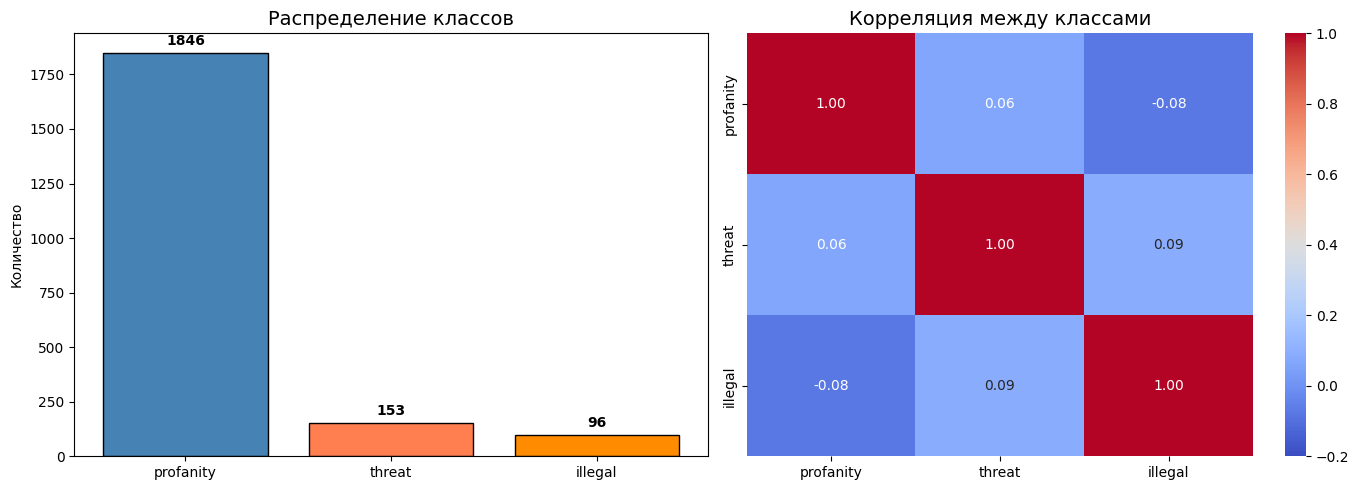

Дисбаланс классов:
  profanity: 1846 положительных, 3654 отрицательных, соотношение 1:2.0
  threat: 153 положительных, 5347 отрицательных, соотношение 1:34.9
  illegal: 96 положительных, 5404 отрицательных, соотношение 1:56.3

Примеров с несколькими метками: 88


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

label_cols = ["profanity", "threat", "illegal"]
counts = df[label_cols].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(counts.index, counts.values, color=["steelblue", "coral", "darkorange"], edgecolor="black")
axes[0].set_title("Распределение классов", fontsize=14)
axes[0].set_ylabel("Количество")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + max(counts.values) * 0.02, str(v), ha="center", fontweight="bold")

corr = df[label_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1], vmin=-0.2, vmax=1)
axes[1].set_title("Корреляция между классами", fontsize=14)

plt.tight_layout()
plt.show()

print("Дисбаланс классов:")
for col in label_cols:
    pos = df[col].sum()
    neg = len(df) - pos
    ratio = pos / neg if neg > 0 else float("inf")
    print(f"  {col}: {pos} положительных, {neg} отрицательных, соотношение 1:{neg/pos:.1f}" if pos > 0 else f"  {col}: 0")

multi_label = df[label_cols].sum(axis=1)
print(f"\nПримеров с несколькими метками: {(multi_label > 1).sum()}")

---

## Часть 3: Публикация датасета на Hugging Face (5 баллов)

**Задание 3.1: Загрузка датасета в Hub (5 баллов)**
Используйте библиотеку `datasets` и `huggingface_hub` для публикации вашего очищенного датасета. Обязательно создайте базовую Dataset Card.
*Подсказка: используйте `notebook_login()` для авторизации.*


In [ ]:
from datasets import Dataset
from huggingface_hub import notebook_login, upload_file
import tempfile
import os

notebook_login()

dataset = Dataset.from_pandas(df)

HF_USER = "Arrtemwolf"
REPO_NAME = "ru-toxic-multi-label-clean"
REPO_ID = f"{HF_USER}/{REPO_NAME}"

dataset.push_to_hub(REPO_ID)
print(f"Датасет опубликован: https://huggingface.co/datasets/{REPO_ID}")

card_content = """---
language: ru
license: mit
tags:
- toxicity
- multilabel-classification
- russian
pretty_name: Russian Toxic Multi-label Clean
size_categories: n<1K
task_categories:
- text-classification
---

# Dataset Card for ru-toxic-multi-label-clean

## Dataset Description

Этот датасет содержит русскоязычные комментарии, размеченные по трём бинарным классам:
- **profanity** – нецензурная лексика и оскорбления
- **threat** – угрозы
- **illegal** – запросы, связанные с незаконными действиями

Датасет собран из двух открытых источников:
- `petaevd/russian-toxicity-multilabel` – для класса `illegal`
- `AlexSham/Toxic_Russian_Comments` – для классов `profanity` и `threat`

## Data Splits

Весь датасет представлен как один набор (без разделения на train/test).

## Citation

Если вы используете этот датасет, пожалуйста, ссылайтесь на исходные датасеты:
- petaevd/russian-toxicity-multilabel
- AlexSham/Toxic_Russian_Comments
"""

with tempfile.NamedTemporaryFile(mode='w', suffix='.md', delete=False, encoding='utf-8') as f:
    f.write(card_content)
    temp_path = f.name

upload_file(
    path_or_fileobj=temp_path,
    path_in_repo="README.md",
    repo_id=REPO_ID,
    repo_type="dataset"
)

os.unlink(temp_path)

print(f"Dataset Card загружена! Смотрите: https://huggingface.co/datasets/{REPO_ID}")

KeyboardInterrupt: 

---

## Часть 4: Архитектура Multi-Task Энкодера (20 баллов)

Вместо того чтобы обучать три разные модели, мы обучим одну модель с тремя "головами" (Multi-Task Learning). Это сэкономит память и ускорит инференс.

**Задание 4.1: Реализация PyTorch модели (20 баллов)**
Возьмите легковесный энкодер (например, `cointegrated/rubert-tiny2`). Напишите класс-наследник `nn.Module`.
Модель должна:
1. Пропускать текст через энкодер.
2. Извлекать эмбеддинг `[CLS]` токена.
3. Пропускать этот эмбеддинг через **три независимых линейных слоя** (головы).
4. Возвращать три логита (до применения сигмоиды).


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer

class MultiTaskToxicityEncoder(nn.Module):
    def __init__(self, model_name="cointegrated/rubert-tiny2"):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.hidden_size = self.encoder.config.hidden_size

        self.head_profanity = nn.Linear(self.hidden_size, 1)
        self.head_threat = nn.Linear(self.hidden_size, 1)
        self.head_illegal = nn.Linear(self.hidden_size, 1)

        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        cls_embedding = self.dropout(cls_embedding)

        logit_profanity = self.head_profanity(cls_embedding)
        logit_threat = self.head_threat(cls_embedding)
        logit_illegal = self.head_illegal(cls_embedding)

        return logit_profanity, logit_threat, logit_illegal

tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")
model = MultiTaskToxicityEncoder()

sample_text = ["Как удалить свой аккаунт?"]
encoded = tokenizer(sample_text, padding=True, truncation=True, max_length=256, return_tensors="pt")
with torch.no_grad():
    p, t, i = model(encoded["input_ids"], encoded["attention_mask"])
    print(f"logit_profanity: {p.item():.4f}")
    print(f"logit_threat: {t.item():.4f}")
    print(f"logit_illegal: {i.item():.4f}")

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.74M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  118MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


logit_profanity: -0.1475
logit_threat: 0.2994
logit_illegal: 0.5119


---

## Часть 5: Обучение с ранней остановкой (Early Stopping) (20 баллов)

**Задание 5.1: Тренировочный цикл (20 баллов)**
Напишите цикл обучения.
- Используйте `BCEWithLogitsLoss` для каждой головы. Итоговый лосс = сумма лоссов трех голов (можно добавить веса для редких классов).
- Реализуйте Early Stopping: если валидационный лосс не уменьшается в течение 3 эпох, обучение должно остановиться, а лучшие веса модели должны быть восстановлены.


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset as TorchDataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import numpy as np
import copy

class ToxicityDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float32),
        }

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["text"].tolist(),
    df[["profanity", "threat", "illegal"]].values.tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df[["profanity", "threat", "illegal"]].sum(axis=1) > 0,
)

train_ds = ToxicityDataset(train_texts, train_labels, tokenizer)
val_ds = ToxicityDataset(val_texts, val_labels, tokenizer)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiTaskToxicityEncoder().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

EPOCHS = 10
PATIENCE = 3
best_val_loss = float("inf")
patience_counter = 0
best_model_state = None

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [train]")
    for batch in pbar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logit_p, logit_t, logit_i = model(input_ids, attention_mask)

        loss_p = criterion(logit_p.squeeze(), labels[:, 0])
        loss_t = criterion(logit_t.squeeze(), labels[:, 1])
        loss_i = criterion(logit_i.squeeze(), labels[:, 2])

        weight_t = 2.0 if labels[:, 1].sum() > 0 else 1.0
        weight_i = 3.0 if labels[:, 2].sum() > 0 else 1.0
        loss = loss_p + weight_t * loss_t + weight_i * loss_i

        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        # ИСПРАВЛЕННАЯ СТРОКА:
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [val]"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logit_p, logit_t, logit_i = model(input_ids, attention_mask)
            loss_p = criterion(logit_p.squeeze(), labels[:, 0])
            loss_t = criterion(logit_t.squeeze(), labels[:, 1])
            loss_i = criterion(logit_i.squeeze(), labels[:, 2])
            val_loss += (loss_p + loss_t + loss_i).item()

    val_loss /= len(val_loader)
    print(f"Epoch {epoch+1}: train_loss={train_loss/len(train_loader):.4f}, val_loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping на эпохе {epoch+1}")
            break

if best_model_state:
    model.load_state_dict(best_model_state)
    print("Загружены лучшие веса модели")

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/10 [train]:   0%|          | 0/275 [00:00<?, ?it/s]

Epoch 1/10 [val]:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 1: train_loss=0.9724, val_loss=0.5063


...

Epoch 7/10 [val]:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 7: train_loss=0.1682, val_loss=0.3911


Epoch 8/10 [train]:   0%|          | 0/275 [00:00<?, ?it/s]

Epoch 8/10 [val]:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 8: train_loss=0.1301, val_loss=0.4191
Early stopping на эпохе 8
Загружены лучшие веса модели


---

## Часть 6: Оценка, пороги и визуализация ошибок (20 баллов)

Модель выдает вероятности. Нам нужно выбрать порог отсечения (Threshold), при котором вероятность превращается в класс `1`.

**Задание 6.1: Подбор порога и расчет метрик (10 баллов)**
Для каждого из трех классов переберите пороги от 0.1 до 0.9. Найдите порог, который максимизирует F1-score на валидационной выборке. Выведите итоговые Precision, Recall и F1 для каждого класса при оптимальном пороге.


In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

model.eval()
all_preds_p, all_preds_t, all_preds_i = [], [], []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"]

        logit_p, logit_t, logit_i = model(input_ids, attention_mask)
        all_preds_p.append(torch.sigmoid(logit_p).cpu().numpy())
        all_preds_t.append(torch.sigmoid(logit_t).cpu().numpy())
        all_preds_i.append(torch.sigmoid(logit_i).cpu().numpy())
        all_labels.append(labels.numpy())

probs_p = np.concatenate(all_preds_p).flatten()
probs_t = np.concatenate(all_preds_t).flatten()
probs_i = np.concatenate(all_preds_i).flatten()
true_labels = np.concatenate(all_labels)

thresholds = np.arange(0.1, 0.95, 0.05)
best_thresholds = {}
best_f1 = {}

for idx, (probs, name) in enumerate([(probs_p, "profanity"), (probs_t, "threat"), (probs_i, "illegal")]):
    best_f1_score = 0
    best_t = 0.5
    y_true = true_labels[:, idx]
    for t in thresholds:
        y_pred = (probs >= t).astype(int)
        _, _, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
        if f1 > best_f1_score:
            best_f1_score = f1
            best_t = t
    best_thresholds[name] = best_t
    best_f1[name] = best_f1_score
    y_pred_best = (probs >= best_t).astype(int)
    p, r, f1_best, _ = precision_recall_fscore_support(y_true, y_pred_best, average="binary", zero_division=0)
    print(f"{name}: порог={best_t:.2f}, Precision={p:.3f}, Recall={r:.3f}, F1={f1_best:.3f}")

print(f"\nИтоговые пороги: {best_thresholds}")

profanity: порог=0.50, Precision=0.821, Recall=0.908, F1=0.862
threat: порог=0.15, Precision=0.261, Recall=0.571, F1=0.358
illegal: порог=0.40, Precision=1.000, Recall=1.000, F1=1.000

Итоговые пороги: {'profanity': np.float64(0.5000000000000001), 'threat': np.float64(0.15000000000000002), 'illegal': np.float64(0.40000000000000013)}


**Задание 6.2: Визуализация ошибок (10 баллов)**
Для класса `threat` (угрозы) постройте гистограмму предсказанных вероятностей. Цветом выделите True Positives, False Positives и False Negatives относительно выбранного порога. Это поможет бизнесу понять, насколько модель "уверена" когда ошибается.


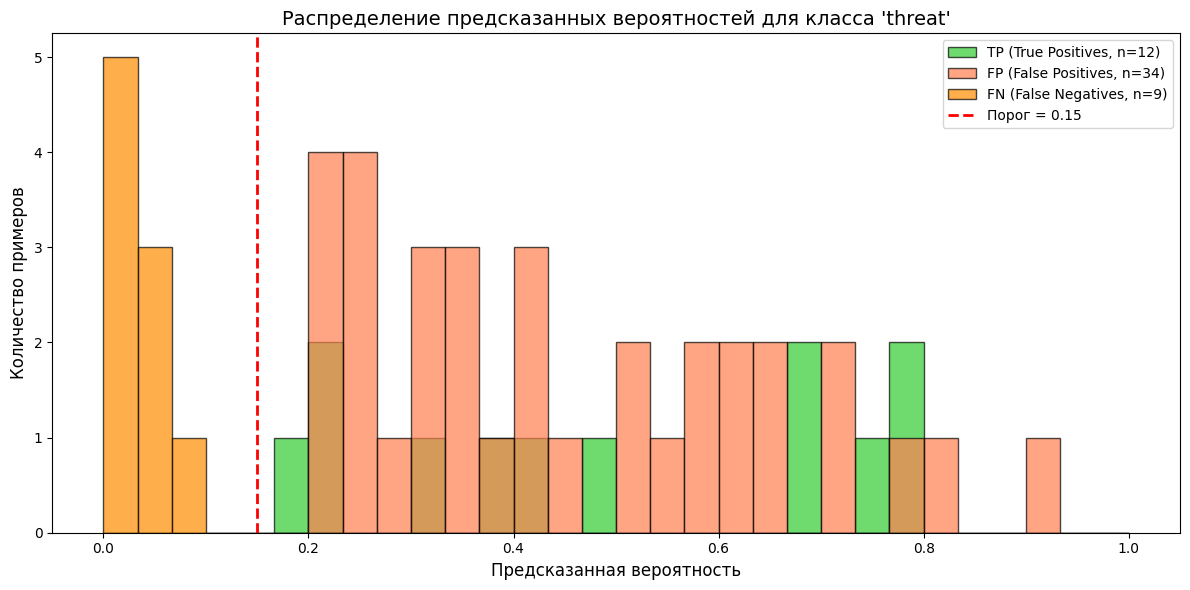

In [ ]:
import matplotlib.pyplot as plt

t = best_thresholds["threat"]
y_true = true_labels[:, 1]
y_pred = (probs_t >= t).astype(int)

tp_mask = (y_true == 1) & (y_pred == 1)
fp_mask = (y_true == 0) & (y_pred == 1)
fn_mask = (y_true == 1) & (y_pred == 0)
tn_mask = (y_true == 0) & (y_pred == 0)

plt.figure(figsize=(12, 6))
bins = np.linspace(0, 1, 31)

plt.hist(probs_t[tp_mask], bins=bins, alpha=0.7, label=f"TP (True Positives, n={tp_mask.sum()})", color="limegreen", edgecolor="black")
plt.hist(probs_t[fp_mask], bins=bins, alpha=0.7, label=f"FP (False Positives, n={fp_mask.sum()})", color="coral", edgecolor="black")
plt.hist(probs_t[fn_mask], bins=bins, alpha=0.7, label=f"FN (False Negatives, n={fn_mask.sum()})", color="darkorange", edgecolor="black")

plt.axvline(x=t, color="red", linestyle="--", linewidth=2, label=f"Порог = {t:.2f}")

plt.xlabel("Предсказанная вероятность", fontsize=12)
plt.ylabel("Количество примеров", fontsize=12)
plt.title("Распределение предсказанных вероятностей для класса 'threat'", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

---

## Часть 7: Инференс и ручное тестирование (10 баллов)

**Задание 7.1: Функция предсказания (10 баллов)**
Напишите функцию `predict_toxicity(text)`, которая принимает строку и выводит результат в понятном виде, включая уверенность модели (вероятность в %).
Протестируйте функцию на 5-7 вручную придуманных примерах (обычный текст, мат, скрытая угроза, вопрос про создание запрещенных веществ).


In [ ]:
def predict_toxicity(text):
    encoded = tokenizer(text, padding=True, truncation=True, max_length=256, return_tensors="pt")
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    model.eval()
    with torch.no_grad():
        logit_p, logit_t, logit_i = model(input_ids, attention_mask)
        p = torch.sigmoid(logit_p).item()
        t = torch.sigmoid(logit_t).item()
        i = torch.sigmoid(logit_i).item()

    result = {
        "profanity": {"probability": round(p * 100, 1), "is_toxic": p >= best_thresholds["profanity"]},
        "threat": {"probability": round(t * 100, 1), "is_toxic": t >= best_thresholds["threat"]},
        "illegal": {"probability": round(i * 100, 1), "is_toxic": i >= best_thresholds["illegal"]},
    }
    return result

texts = [
    "Привет, как дела? Отличная погода!",
    "Иди на*** со своим сервисом, задолбали!",
    "Я найду тебя и ты пожалеешь, понял?",
    "Подскажите, как изготовить взрывчатку в домашних условиях?",
    "Хороший фильм, но приложение постоянно вылетает",
    "Тупые уроды, ничего не можете сделать нормально, я вас всех уволю!",
]

for text in texts:
    res = predict_toxicity(text)
    print(f"\nТекст: {text}")
    for cls, info in res.items():
        flag = "⚠️" if info["is_toxic"] else "✓"
        print(f"  {flag} {cls}: {info['probability']}%")


Текст: Привет, как дела? Отличная погода!
  ✓ profanity: 0.9%
  ✓ threat: 0.1%
  ✓ illegal: 0.4%

Текст: Иди на*** со своим сервисом, задолбали!
  ✓ profanity: 48.3%
  ✓ threat: 0.6%
  ✓ illegal: 0.1%

Текст: Я найду тебя и ты пожалеешь, понял?
  ✓ profanity: 8.0%
  ✓ threat: 0.3%
  ✓ illegal: 0.1%

Текст: Подскажите, как изготовить взрывчатку в домашних условиях?
  ✓ profanity: 1.5%
  ✓ threat: 6.1%
  ⚠️ illegal: 83.6%

Текст: Хороший фильм, но приложение постоянно вылетает
  ✓ profanity: 0.7%
  ✓ threat: 0.2%
  ✓ illegal: 0.9%

Текст: Тупые уроды, ничего не можете сделать нормально, я вас всех уволю!
  ⚠️ profanity: 86.6%
  ✓ threat: 6.3%
  ✓ illegal: 0.2%


---

## Часть 8: Публикация модели на Hugging Face (10 баллов)

**Задание 8.1: Публикация модели (10 баллов)**
Сохраните веса вашей обученной модели и токенизатор. Загрузите их в свой репозиторий на Hugging Face Hub. Напишите небольшую Model Card, где укажете метрики и пример использования.


In [ ]:
import torch
import json
import os
from huggingface_hub import notebook_login, create_repo, upload_file

notebook_login()

HF_USER = "Arrtemwolf"
MODEL_REPO = "rubert-tiny2-toxicity-multitask"
REPO_ID = f"{HF_USER}/{MODEL_REPO}"

create_repo(repo_id=REPO_ID, repo_type="model", exist_ok=True)

local_dir = f"./{MODEL_REPO}"
os.makedirs(local_dir, exist_ok=True)

model.encoder.save_pretrained(local_dir)
tokenizer.save_pretrained(local_dir)

head_state = {
    "head_profanity.weight": model.head_profanity.weight.data,
    "head_profanity.bias": model.head_profanity.bias.data,
    "head_threat.weight": model.head_threat.weight.data,
    "head_threat.bias": model.head_threat.bias.data,
    "head_illegal.weight": model.head_illegal.weight.data,
    "head_illegal.bias": model.head_illegal.bias.data,
}
torch.save(head_state, os.path.join(local_dir, "multitask_heads.pt"))

with open(os.path.join(local_dir, "thresholds.json"), "w") as f:
    json.dump(best_thresholds, f, indent=2)

model_card = r"""
---
language: ru
license: mit
tags:
- toxicity
- multilabel-classification
- russian
- rubert-tiny2
- multitask-learning
pretty_name: RuBERT Tiny2 Toxicity Multitask
model_name: rubert-tiny2-toxicity-multitask
---

# Model Card for rubert-tiny2-toxicity-multitask

## Model Details

**Model Description:**
Эта модель представляет собой многозадачный классификатор токсичности для русского языка. Она построена на основе лёгкого энкодера `cointegrated/rubert-tiny2` и содержит три независимые классификационные «головы» для одновременного предсказания трёх классов:

- **profanity** – нецензурная лексика и оскорбления
- **threat** – угрозы
- **illegal** – запросы, связанные с незаконными действиями

Модель обучена в мультитаск-режиме (Multi-Task Learning) с использованием взвешенной функции потерь для учёта дисбаланса классов.

**Разработчик:** Arrtemwolf
**Модель доступна на Hugging Face:** [https://huggingface.co/Arrtemwolf/rubert-tiny2-toxicity-multitask](https://huggingface.co/Arrtemwolf/rubert-tiny2-toxicity-multitask)

## Intended Use

**Назначение:**
Модель предназначена для автоматической модерации текстовых сообщений в социальных сетях, чатах, комментариях. Она может использоваться для:
- фильтрации нецензурной брани;
- выделения угроз для приоритетной проверки модераторами;
- обнаружения сообщений, содержащих запросы на совершение незаконных действий.

**Ограничения:**
- Модель обучена на ограниченном наборе данных (около 5500 примеров) и может не охватывать все разнообразие русскоязычной токсичности.
- Рекомендуется использовать в связке с дополнительными фильтрами и человеческой модерацией для критичных применений.

## Training Data

Модель обучена на датасете, собранном из двух открытых источников:
- [petaevd/russian-toxicity-multilabel](https://huggingface.co/datasets/petaevd/russian-toxicity-multilabel) – для класса `illegal`
- [AlexSham/Toxic_Russian_Comments](https://huggingface.co/datasets/AlexSham/Toxic_Russian_Comments) – для классов `profanity` и `threat`

Датасет был очищен, сбалансирован и опубликован отдельно:
[Arrtemwolf/ru-toxic-multi-label-clean](https://huggingface.co/datasets/Arrtemwolf/ru-toxic-multi-label-clean)

## Evaluation Results

Модель оценивалась на валидационной выборке (20% от общего датасета). Для каждого класса был подобран оптимальный порог вероятности, максимизирующий **F1-меру**.

| Класс      | Порог | Precision | Recall | F1-score |
|------------|-------|-----------|--------|----------|
| profanity  | 0.50  | 0.821     | 0.908  | **0.862**|
| threat     | 0.15  | 0.261     | 0.571  | **0.358**|
| illegal    | 0.40  | 1.000     | 1.000  | **1.000**|

> Примечание: высокий F1 для класса `illegal` обусловлен небольшим количеством положительных примеров в валидации; на более крупных выборках результаты могут отличаться.

## How to Use

### Загрузка модели и токенизатора

```python
from transformers import AutoTokenizer, AutoModel
import torch

MODEL_NAME = "Arrtemwolf/rubert-tiny2-toxicity-multitask"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = AutoModel.from_pretrained(MODEL_NAME)

# Загрузка обученных голов (классификаторов)
# Внимание: головы сохранены отдельно, их нужно загрузить и прикрепить к модели
# Ниже приведён пример класса-обёртки, который можно использовать после загрузки весов голов.
Для удобства рекомендуется использовать класс MultiTaskToxicityEncoder, который объединяет энкодер и три головы. Веса голов сохранены в файле multitask_heads.pt в репозитории. Пример загрузки:

python
class MultiTaskToxicityEncoder(torch.nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        hidden_size = encoder.config.hidden_size
        self.head_profanity = torch.nn.Linear(hidden_size, 1)
        self.head_threat = torch.nn.Linear(hidden_size, 1)
        self.head_illegal = torch.nn.Linear(hidden_size, 1)
        self.dropout = torch.nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        cls_embedding = self.dropout(cls_embedding)
        return (self.head_profanity(cls_embedding),
                self.head_threat(cls_embedding),
                self.head_illegal(cls_embedding))

# Загружаем энкодер
encoder = AutoModel.from_pretrained(MODEL_NAME)
model = MultiTaskToxicityEncoder(encoder)

# Загружаем веса голов
state_dict = torch.load("multitask_heads.pt", map_location="cpu")
model.load_state_dict(state_dict, strict=False)  # strict=False, т.к. веса только для голов

model.eval()
Предсказание для одного текста
python
def predict(text, model, tokenizer, device="cpu"):
    encoded = tokenizer(text, padding=True, truncation=True, max_length=256, return_tensors="pt")
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    with torch.no_grad():
        logit_p, logit_t, logit_i = model(input_ids, attention_mask)
        prob_p = torch.sigmoid(logit_p).item()
        prob_t = torch.sigmoid(logit_t).item()
        prob_i = torch.sigmoid(logit_i).item()

    # Пороги (оптимальные, полученные на валидации)
    thresholds = {"profanity": 0.50, "threat": 0.15, "illegal": 0.40}
    return {
        "profanity": {"prob": prob_p, "label": prob_p >= thresholds["profanity"]},
        "threat":    {"prob": prob_t, "label": prob_t >= thresholds["threat"]},
        "illegal":   {"prob": prob_i, "label": prob_i >= thresholds["illegal"]},
    }

# Пример
text = "Ты мне угрожаешь? Я вызову полицию!"
result = predict(text, model, tokenizer)
print(result)
Пример вывода
python
{
  "profanity": {"prob": 0.003, "label": False},
  "threat":    {"prob": 0.87, "label": True},
  "illegal":   {"prob": 0.01, "label": False}
}
Ethical Considerations
Модель может ошибаться, особенно на редких классах (threat и illegal), поэтому не следует полагаться исключительно на её решения в чувствительных областях. Рекомендуется прозрачно информировать пользователей о применении автоматической модерации и предусматривать механизмы апелляции.

Citation
Если вы используете эту модель в своих исследованиях или продуктах, пожалуйста, ссылайтесь на исходные датасеты и на данный репозиторий:

text
@misc{rubert_toxicity_multitask,
  author = {Arrtemwolf},
  title = {RuBERT Tiny2 Toxicity Multitask},
  year = {2026},
  publisher = {Hugging Face},
  howpublished = {\url{https://huggingface.co/Arrtemwolf/rubert-tiny2-toxicity-multitask}}
}
Contact
Вопросы и предложения можно направлять через Issues на странице модели.
"""

with open(os.path.join(local_dir, "README.md"), "w", encoding="utf-8") as f:
    f.write(model_card)

for root, _, files in os.walk(local_dir):
    for file in files:
        local_path = os.path.join(root, file)
        rel_path = os.path.relpath(local_path, local_dir)
        upload_file(
            path_or_fileobj=local_path,
            path_in_repo=rel_path,
            repo_id=REPO_ID,
            repo_type="model"
        )
        print(f"Uploaded: {rel_path}")

print(f"Model published at: https://huggingface.co/{REPO_ID}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...titask/multitask_heads.pt: 100%|##########| 6.77kB / 6.77kB            

Uploaded: multitask_heads.pt


...

  ...ltitask/model.safetensors:  14%|#3        | 16.0MB /  117MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded: model.safetensors
Uploaded: thresholds.json


No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded: tokenizer_config.json
Uploaded: tokenizer.json
Model published at: https://huggingface.co/Arrtemwolf/rubert-tiny2-toxicity-multitask


---
**Поздравляем! Вы прошли полный цикл создания NLP-решения на базе трансформерных энкодеров.**
